# The Error-State Kalman Filter for temporally consistent 6D pose estimation

A per-frame 6D pose estimator looks at every camera image on its own. It has no memory of the previous frame, so its output is **not temporally consistent**: the pose jitters from frame to frame, it is sometimes completely wrong, it can flip between symmetric solutions, and it is missing whenever the object is not detected.

This notebook shows how an **Error-State Kalman Filter (ESKF)** turns such per-frame estimates into a smooth, robust and honest track. We build the filter from first principles in small steps, and test every piece before we use it.

It is written in the spirit of Roger Labbe's [*Kalman and Bayesian Filters in Python*](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python) and follows the notation of

> J. Solà, *Quaternion kinematics for the error-state Kalman filter*, 2017. [arXiv:1711.02508](https://arxiv.org/abs/1711.02508)

**Contents**

1. The problem, and the idea of filtering
2. Why an *error-state* filter for poses?
3. A small quaternion toolbox
4. The data: a simulated per-frame pose estimator
5. True, nominal and error state
6. Prediction: a constant-velocity motion model
7. Correction: using one pose estimate
8. A first filter
9. Robustness: symmetry flips and outlier gating
10. Temporal consistency: results
11. Tuning: smoothness versus lag
12. Is the filter honest? NEES and NIS
13. Filter versus smoother: using future frames
14. Summary and references

Run the cells from top to bottom.

In [1]:
%matplotlib inline
import os
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

## 1. The problem, and the idea of filtering

A per-frame estimator (for example a render-and-compare method such as FoundationPose) gives one pose $(\mathbf p_m, \mathbf q_m)$ of the object in the camera frame for every image. Four things go wrong from the point of view of temporal consistency:

| problem | what you see | cause |
|---|---|---|
| **jitter** | the pose shakes by millimetres and degrees, even when nothing moves | random error of each frame, e.g. from image noise and depth noise |
| **outliers** | a single frame is completely wrong | wrong match, wrong mask, bad depth |
| **symmetry flips** | the pose jumps by 180° and back | a near-symmetric object looks the same from both sides |
| **dropouts** | no pose for some frames | occlusion, turbidity, detection failure |

On top of that, the quality is not constant: estimates get worse with distance and in poor visibility.

**The idea of filtering.** A filter adds memory. At every frame it holds two opinions about the pose:

1. **Prediction:** "given where the object was and how it was moving, it should be *here* now".
2. **Measurement:** "the estimator says it is *there*".

The Kalman filter blends the two, weighted by how uncertain each one is. If the prediction is more certain than the measurement, the filter moves only part of the way towards the measurement, and the random part of each frame's error averages out over time. That is how jitter is reduced. The same machinery also lets us reject measurements that disagree too much with the prediction (outliers, flips), and keep predicting when measurements are missing.

**What a filter cannot do.** It removes *random* error, not *systematic* error: if every estimate is 2 cm too far away, the filtered track will be smoothly 2 cm too far away. And there is always a trade-off: trusting the prediction more gives a smoother track, but it reacts later to real motion (Section 11).

## 2. Why an *error-state* filter for poses?

A plain Kalman filter estimates the state directly. That is fine for position, but awkward for **orientation**:

* A unit quaternion has 4 numbers but only 3 degrees of freedom. A $4\times4$ covariance on it is singular in the direction that would violate $\|\mathbf q\|=1$, and after every update the quaternion leaves the unit sphere and must be renormalised, which the covariance knows nothing about.
* Euler angles have 3 numbers, but they have singularities (gimbal lock) and are strongly non-linear.

The ESKF splits the state in two:

| | **nominal state** $\mathbf x$ | **error state** $\delta\mathbf x$ |
|---|---|---|
| holds | the large signal, e.g. a quaternion | the small deviation from it |
| updated | non-linearly, without noise | linearly, carries all uncertainty |
| orientation | $\mathbf q$ (4 numbers, unit length) | $\delta\boldsymbol\theta\in\mathbb R^3$ (3 numbers, minimal) |

The covariance lives on the small error state, so it is $3\times3$ for orientation and never singular. The error stays close to zero, where the linearisation is accurate. And, as we will see in Section 7, a 6D pose measurement gets a very simple Jacobian in this formulation.

## 3. A small quaternion toolbox

We only need a handful of rotation operations. We build them one at a time and test each one.

Conventions used throughout:

* Hamilton quaternions, stored as $\mathbf q = [q_w, q_x, q_y, q_z]$.
* $\mathbf q$ rotates object-frame vectors into the camera frame: $\mathbf x_{cam} = \mathbf R(\mathbf q)\,\mathbf x_{obj}$.

### 3.1 The skew-symmetric matrix

$[\mathbf a]_\times$ turns a cross product into a matrix product: $[\mathbf a]_\times\mathbf b = \mathbf a\times\mathbf b$.

In [2]:
def skew(a):
    """[a]x such that skew(a) @ b == np.cross(a, b)."""
    x, y, z = a
    return np.array([[0.0, -z,   y],
                     [z,   0.0, -x],
                     [-y,  x,   0.0]])

In [3]:
a, b = np.array([1.0, 2.0, 3.0]), np.array([-0.5, 0.4, 2.0])
print("skew(a) @ b  :", skew(a) @ b)
print("np.cross(a,b):", np.cross(a, b))

skew(a) @ b  : [ 2.8 -3.5  1.4]
np.cross(a,b): [ 2.8 -3.5  1.4]


### 3.2 Quaternion product and conjugate

Composing two rotations is the quaternion product $\mathbf p\otimes\mathbf q$ (Solà eq. 12). The conjugate $\mathbf q^* = [q_w, -q_x, -q_y, -q_z]$ is the inverse rotation.

In [4]:
def q_mult(p, q):
    """Quaternion product p ⊗ q."""
    pw, px, py, pz = p
    qw, qx, qy, qz = q
    return np.array([pw*qw - px*qx - py*qy - pz*qz,
                     pw*qx + px*qw + py*qz - pz*qy,
                     pw*qy - px*qz + py*qw + pz*qx,
                     pw*qz + px*qy - py*qx + pz*qw])


def q_conj(q):
    """Conjugate q*, the inverse of a unit quaternion."""
    return np.array([q[0], -q[1], -q[2], -q[3]])

In [5]:
q = np.array([0.8, 0.2, -0.4, 0.4]); q = q / np.linalg.norm(q)
p = np.array([0.6, 0.0, 0.8, 0.0])
print("q ⊗ q* :", q_mult(q, q_conj(q)), " (identity)")
print("p ⊗ q  :", q_mult(p, q))
print("q ⊗ p  :", q_mult(q, p), " (different: rotations do not commute)")

q ⊗ q* : [1. 0. 0. 0.]  (identity)
p ⊗ q  : [0.8  0.44 0.4  0.08]
q ⊗ p  : [ 0.8 -0.2  0.4  0.4]  (different: rotations do not commute)


### 3.3 Exp and Log: rotation vectors and quaternions

A rotation by angle $\theta$ about unit axis $\mathbf u$ can be written as the 3-vector $\boldsymbol\theta=\theta\mathbf u$. The exponential and logarithmic maps convert between the two forms (Solà eqs. 101, 105):

$$
\mathrm{Exp}(\theta\mathbf u) = \begin{bmatrix}\cos(\theta/2)\\ \mathbf u\sin(\theta/2)\end{bmatrix},
\qquad
\mathrm{Log}(\mathbf q) = \theta\mathbf u .
$$

These two maps are the key to the ESKF: the orientation *error* will be a small 3-vector $\delta\boldsymbol\theta$, and Exp turns it into a quaternion we can apply.

In [6]:
def q_normalize(q):
    return q / np.linalg.norm(q)


def q_exp(rotvec):
    """Rotation vector θu  ->  unit quaternion."""
    rotvec = np.asarray(rotvec, dtype=float)
    theta = np.linalg.norm(rotvec)
    if theta < 1e-10:                                   # tiny angle: first-order approximation
        return q_normalize(np.array([1.0, *(0.5 * rotvec)]))
    u = rotvec / theta
    return np.array([np.cos(theta / 2), *(np.sin(theta / 2) * u)])


def q_log(q):
    """Unit quaternion  ->  rotation vector θu."""
    q = np.asarray(q, dtype=float)
    if q[0] < 0:                                        # q and -q are the same rotation
        q = -q
    v = q[1:]
    norm_v = np.linalg.norm(v)
    if norm_v < 1e-10:
        return 2.0 * v
    return 2.0 * np.arctan2(norm_v, q[0]) * v / norm_v

In [7]:
theta = np.array([0.0, 0.0, np.pi / 2])                 # 90° about z
print("Exp(90° about z) :", q_exp(theta))
print("Log(Exp(θ)) == θ :", np.allclose(q_log(q_exp(theta)), theta))
print("Log(-q) == Log(q):", np.allclose(q_log(-q_exp(theta)), theta))

Exp(90° about z) : [0.7071 0.     0.     0.7071]
Log(Exp(θ)) == θ : True
Log(-q) == Log(q): True


### 3.4 Rotation matrix

For rotating vectors we convert $\mathbf q$ to a $3\times3$ rotation matrix $\mathbf R(\mathbf q)$ (Solà eq. 115).

In [8]:
def q_to_R(q):
    """Rotation matrix with x_cam = R @ x_obj."""
    w, x, y, z = q
    return np.array([[1 - 2*(y*y + z*z), 2*(x*y - w*z),     2*(x*z + w*y)],
                     [2*(x*y + w*z),     1 - 2*(x*x + z*z), 2*(y*z - w*x)],
                     [2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x*x + y*y)]])

In [9]:
R = q_to_R(q_exp([0.0, 0.0, np.pi / 2]))
print("x-axis rotated 90° about z:", R @ np.array([1.0, 0.0, 0.0]), " (should be the y-axis)")
print("R Rᵀ == I:", np.allclose(R @ R.T, np.eye(3)))

x-axis rotated 90° about z: [0. 1. 0.]  (should be the y-axis)
R Rᵀ == I: True


### 3.5 "Plus" and "minus" for rotations

Rotations cannot be added and subtracted like vectors, but Exp and Log give us the equivalent operations. We use a **local** perturbation, applied in the object frame (on the right):

$$
\mathbf q \boxplus \delta\boldsymbol\theta = \mathbf q \otimes \mathrm{Exp}(\delta\boldsymbol\theta),
\qquad
\mathbf q_1 \boxminus \mathbf q_0 = \mathrm{Log}(\mathbf q_0^{*} \otimes \mathbf q_1).
$$

$\boxplus$ applies a small rotation. $\boxminus$ answers "which rotation takes $\mathbf q_0$ to $\mathbf q_1$?". Its length $\|\mathbf q_1\boxminus\mathbf q_0\|$ is the angle between two orientations, which we will use as the rotation error.

In [10]:
def q_boxplus(q, dtheta):
    """q ⊞ δθ : apply a small object-frame rotation δθ to q."""
    return q_normalize(q_mult(q, q_exp(dtheta)))


def q_boxminus(q1, q0):
    """q1 ⊟ q0 : the object-frame rotation that takes q0 to q1."""
    return q_log(q_mult(q_conj(q0), q1))


def rotation_angle_deg(q1, q0):
    """Angle between two orientations, in degrees."""
    return np.degrees(np.linalg.norm(q_boxminus(q1, q0)))

In [11]:
q0 = q_exp([0.3, -0.2, 0.5])
dtheta = np.array([0.01, -0.02, 0.03])
q1 = q_boxplus(q0, dtheta)
print("(q0 ⊞ δθ) ⊟ q0 :", q_boxminus(q1, q0), " (should equal δθ)")
print("angle between  :", round(rotation_angle_deg(q1, q0), 3), "deg =", round(np.degrees(np.linalg.norm(dtheta)), 3), "deg")

(q0 ⊞ δθ) ⊟ q0 : [ 0.01 -0.02  0.03]  (should equal δθ)
angle between  : 2.144 deg = 2.144 deg


## 4. The data: a simulated per-frame pose estimator

To see what the filter does, we need the ground truth, so we simulate. The scene: a camera on an underwater vehicle observes a static object from about $1.5$–$2.5$ m while the vehicle moves. The *relative* pose of the object in the camera frame therefore changes smoothly. A per-frame estimator runs at 15 Hz and has all the problems from Section 1:

| effect | in the simulation |
|---|---|
| jitter | Gaussian noise, $\sigma_p \approx 1$ cm and $\sigma_\theta\approx 1.5°$ at 1.5 m, growing with distance |
| poor visibility | between 14 s and 20 s the noise is 3× larger ("turbid water") |
| outliers | 3% of frames are a random, completely wrong pose |
| symmetry flips | 5% of frames are flipped by 180° about the object's $z$-axis, a symmetry of the object |
| dropouts | 5% of frames missing at random, plus an occlusion from 26 s to 29 s |

Like a good estimator, it also reports its own uncertainty $\sigma_p,\sigma_\theta$ for every frame. For outliers and flips this reported uncertainty is as small as usual, because the estimator does not know it is wrong. The first second is kept clean so the filter can start on a good estimate.

First the configuration and the true motion:

In [12]:
@dataclass
class SimConfig:
    duration: float = 40.0
    frame_rate: float = 15.0
    sigma_p_base: float = 0.01                # estimator noise at 1.5 m distance [m]
    sigma_theta_base: float = np.deg2rad(1.5) # [rad]
    turbid: tuple = (14.0, 20.0)              # period with 3x noise
    turbid_factor: float = 3.0
    occlusion: tuple = (26.0, 29.0)           # no estimates at all
    p_missing: float = 0.05                   # random missing frames
    p_outlier: float = 0.03
    p_flip: float = 0.05
    clean_start: float = 1.0                  # no outliers / flips in the first second
    seed: int = 0


SYMMETRY = q_exp([0.0, 0.0, np.pi])           # the object looks the same after 180° about its z-axis
SYMMETRIES = [np.array([1.0, 0, 0, 0]), SYMMETRY]

In [13]:
def true_position(t):
    """Object position in the camera frame and its velocity (analytic)."""
    p = np.array([0.30 * np.sin(0.20 * t), 0.15 * np.sin(0.13 * t + 0.5), 2.0 + 0.5 * np.sin(0.10 * t)])
    v = np.array([0.06 * np.cos(0.20 * t), 0.0195 * np.cos(0.13 * t + 0.5), 0.05 * np.cos(0.10 * t)])
    return p, v


def true_angular_velocity(t):
    """Angular velocity of the object relative to the camera, in the object frame [rad/s]."""
    return np.array([0.15 * np.sin(0.3 * t), 0.20 * np.cos(0.2 * t), 0.10 * np.sin(0.15 * t + 1.0)])

The true orientation is obtained by integrating the angular velocity in small sub-steps:

In [14]:
def simulate_truth(cfg):
    dt, n = 1.0 / cfg.frame_rate, int(round(cfg.duration * cfg.frame_rate))
    q = q_exp([0.2, -0.3, 0.4])
    rows = []
    for k in range(n):
        t = k * dt
        p, v = true_position(t)
        rows.append([t, *p, *v, *q, *true_angular_velocity(t)])
        for s in range(20):                                   # integrate q to the next frame
            ts = t + (s + 0.5) * dt / 20
            q = q_boxplus(q, true_angular_velocity(ts) * dt / 20)
    return pd.DataFrame(rows, columns=["t", "px", "py", "pz", "vx", "vy", "vz",
                                       "qw", "qx", "qy", "qz", "wx", "wy", "wz"])

Now the estimator. For every frame it decides whether the object is detected, how noisy this frame is, and whether this frame is an outlier or a flip. The column `kind` records what happened. It is only used for plotting: the filter never sees it.

In [15]:
def noise_level(t, z, cfg):
    """Per-frame noise: grows with distance z, and is 3x larger in turbid water."""
    scale = z / 1.5
    if cfg.turbid[0] <= t < cfg.turbid[1]:
        scale *= cfg.turbid_factor
    return cfg.sigma_p_base * scale, cfg.sigma_theta_base * scale


def estimate_one_frame(t, p, q, cfg, rng):
    """Returns (valid, kind, p_meas, q_meas, sigma_p, sigma_theta) for one frame."""
    if cfg.occlusion[0] <= t < cfg.occlusion[1] or rng.random() < cfg.p_missing:
        return False, "missing", np.full(3, np.nan), np.full(4, np.nan), np.nan, np.nan

    sigma_p, sigma_theta = noise_level(t, p[2], cfg)
    p_m = p + sigma_p * rng.standard_normal(3)                    # jitter
    q_m = q_boxplus(q, sigma_theta * rng.standard_normal(3))
    kind, u = "good", rng.random()
    if t >= cfg.clean_start and u < cfg.p_outlier:                # completely wrong pose
        p_m, q_m, kind = p + rng.normal(0, 0.3, 3), q_normalize(rng.normal(size=4)), "outlier"
    elif t >= cfg.clean_start and u < cfg.p_outlier + cfg.p_flip: # symmetric solution
        q_m, kind = q_mult(q_m, SYMMETRY), "flip"
    return True, kind, p_m, q_m, sigma_p, sigma_theta

In [16]:
def simulate(cfg=SimConfig()):
    rng = np.random.default_rng(cfg.seed)
    truth = simulate_truth(cfg)
    rows = []
    for k in range(len(truth)):
        t = truth.t[k]
        p = truth.loc[k, ["px", "py", "pz"]].to_numpy(dtype=float)
        q = truth.loc[k, ["qw", "qx", "qy", "qz"]].to_numpy(dtype=float)
        valid, kind, p_m, q_m, s_p, s_th = estimate_one_frame(t, p, q, cfg, rng)
        rows.append([t, valid, kind, *p_m, *q_m, s_p, s_th])
    estimates = pd.DataFrame(rows, columns=["t", "valid", "kind", "px", "py", "pz",
                                            "qw", "qx", "qy", "qz", "sigma_p", "sigma_theta"])
    return truth, estimates

Generate the data and save it as CSV. You can replace `data/pose_estimates.csv` with the output of a real estimator (same columns, `kind` can be left empty) and run the rest of the notebook on it.

In [17]:
cfg = SimConfig()
truth, estimates = simulate(cfg)

os.makedirs("data", exist_ok=True)
truth.to_csv("data/ground_truth.csv", index=False, float_format="%.9f")
estimates.to_csv("data/pose_estimates.csv", index=False, float_format="%.9f")

print(f"{len(estimates)} frames:", estimates.kind.value_counts().to_dict())
estimates.head()

600 frames: {'good': 499, 'missing': 73, 'flip': 20, 'outlier': 8}


,t,valid,kind,px,py,pz,qw,qx,qy,qz,sigma_p,sigma_theta
0,0.000000,True,good,-0.001761,0.080453,2.001399,0.961020,0.085134,-0.146159,0.218703,0.013333,0.034907
1,0.066667,True,good,-0.012901,0.064728,2.003885,0.971116,0.061680,-0.151619,0.173610,0.013356,0.034965
2,0.133333,True,good,0.003768,0.079691,2.020613,0.970209,0.089995,-0.112063,0.195030,0.013378,0.035023
3,0.200000,True,good,0.013257,0.065349,1.997648,0.969727,0.087725,-0.125886,0.189966,0.013400,0.035081
4,0.266667,True,good,0.023252,0.079314,2.018102,0.962907,0.080257,-0.129281,0.222835,0.013422,0.035139


Two small helpers let us read a pose from a table row and compare estimates with the truth.

In [18]:
def pose_at(table, k):
    """(p, q) at row k of the truth or estimates table."""
    return (table.loc[k, ["px", "py", "pz"]].to_numpy(dtype=float),
            table.loc[k, ["qw", "qx", "qy", "qz"]].to_numpy(dtype=float))


t = truth.t.to_numpy()
P_TRUE = truth[["px", "py", "pz"]].to_numpy()
Q_TRUE = truth[["qw", "qx", "qy", "qz"]].to_numpy()
P_RAW = estimates[["px", "py", "pz"]].to_numpy()
Q_RAW = estimates[["qw", "qx", "qy", "qz"]].to_numpy()
VALID = estimates.valid.to_numpy(dtype=bool)
KIND = estimates.kind.to_numpy()

Let us look at the raw estimates. Grey bands mark the turbid period (light) and the occlusion (dark).

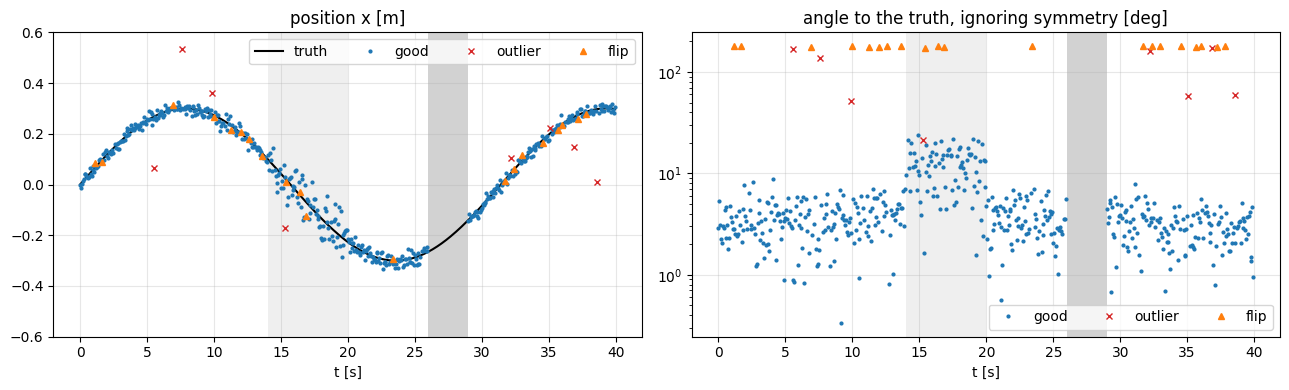

In [19]:
def shade(ax):
    ax.axvspan(*cfg.turbid, color="grey", alpha=0.12, lw=0)
    ax.axvspan(*cfg.occlusion, color="grey", alpha=0.35, lw=0)


raw_rot_err = np.array([rotation_angle_deg(Q_RAW[k], Q_TRUE[k]) if VALID[k] else np.nan for k in range(len(t))])

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(t, P_TRUE[:, 0], "k", lw=1.5, label="truth")
for kind, style in [("good", "C0."), ("outlier", "C3x"), ("flip", "C1^")]:
    m = KIND == kind
    axs[0].plot(t[m], P_RAW[m, 0], style, ms=4, label=kind)
axs[0].set_ylim(-0.6, 0.6); axs[0].set_title("position x [m]"); axs[0].legend(ncol=4)
for kind, style in [("good", "C0."), ("outlier", "C3x"), ("flip", "C1^")]:
    m = KIND == kind
    axs[1].semilogy(t[m], raw_rot_err[m], style, ms=4, label=kind)
axs[1].set_title("angle to the truth, ignoring symmetry [deg]"); axs[1].legend(ncol=3)
for a in axs: shade(a); a.set_xlabel("t [s]")
plt.tight_layout()

The good frames scatter around the truth (jitter), with visibly more scatter in the turbid period. Outliers are far off, flips have a rotation error of about 180°, and during the occlusion there is nothing at all.

### 4.1 Measuring temporal consistency

We need numbers, not only plots. Besides the usual **accuracy** (error with respect to the truth), we measure **jitter**: how much the frame-to-frame motion of a track differs from the true frame-to-frame motion. A perfectly consistent track moves exactly as the object moves, so its jitter is zero, even if it has a constant offset.

$$
\text{jitter}_p = \mathrm{RMS}_k\,\big\|(\hat{\mathbf p}_{k+1}-\hat{\mathbf p}_k) - (\mathbf p_{k+1}-\mathbf p_k)\big\|,
\qquad
\text{jitter}_\theta = \mathrm{RMS}_k\,\big\|(\hat{\mathbf q}_{k+1}\boxminus\hat{\mathbf q}_k) - (\mathbf q_{k+1}\boxminus\mathbf q_k)\big\|
$$

For **accuracy** we measure the rotation error *up to symmetry*, as the BOP benchmark does: for a symmetric object, a flipped pose looks exactly the same, so it is not less accurate. A flip is still a *jump*, though, and the jitter metric catches it. This separates the two questions cleanly: "is the pose right?" and "does the track move consistently?".

For a fair comparison we evaluate every method on the same pairs of consecutive frames in which the raw estimator produced a pose.

In [20]:
PAIRS = np.where(VALID[:-1] & VALID[1:])[0]          # frames k where both k and k+1 have a raw estimate


def rotation_error_deg(q_est, q_true):
    """Rotation error up to the object's symmetry, in degrees."""
    return min(rotation_angle_deg(q_mult(q_est, S), q_true) for S in SYMMETRIES)


def metrics(P_est, Q_est, frames=None):
    """Accuracy and jitter of a track (arrays over all frames). Returns a dict."""
    frames = np.arange(len(t)) if frames is None else frames
    pos_err = np.linalg.norm(P_est[frames] - P_TRUE[frames], axis=1)
    rot_err = np.array([rotation_error_deg(Q_est[k], Q_TRUE[k]) for k in frames])
    jit_p = [np.linalg.norm((P_est[k+1] - P_est[k]) - (P_TRUE[k+1] - P_TRUE[k])) for k in PAIRS]
    jit_q = [np.linalg.norm(q_boxminus(Q_est[k+1], Q_est[k]) - q_boxminus(Q_TRUE[k+1], Q_TRUE[k])) for k in PAIRS]
    rms = lambda e: np.sqrt(np.mean(np.square(e)))
    return {"pos RMSE [cm]": 100 * rms(pos_err), "rot RMSE [deg]": rms(rot_err),
            "pos jitter [cm]": 100 * rms(jit_p), "rot jitter [deg]": np.degrees(rms(jit_q))}

In [21]:
results = pd.DataFrame({"raw estimates": metrics(P_RAW, Q_RAW, np.where(VALID)[0])}).T
results.round(2)

,pos RMSE [cm],rot RMSE [deg],pos jitter [cm],rot jitter [deg]
raw estimates,6.78,14.71,9.4,52.24


The flips no longer count as accuracy errors, but they make the rotation *jitter* enormous: a 180° jump weighs more than hundreds of small ones. The outliers spoil both accuracy and jitter. The goal of the rest of this notebook is to build a filter that brings all four numbers down.

## 5. True, nominal and error state

The filter must know not only *where* the object is, but also *how it moves*, otherwise it cannot predict. Our state is the object pose in the camera frame plus its velocity:

$$
\underbrace{\mathbf x = \begin{bmatrix}\mathbf p\\ \mathbf v\\ \mathbf q\\ \boldsymbol\omega\end{bmatrix}}_{\text{nominal, 13 numbers}}
\qquad
\underbrace{\delta\mathbf x = \begin{bmatrix}\delta\mathbf p\\ \delta\mathbf v\\ \delta\boldsymbol\theta\\ \delta\boldsymbol\omega\end{bmatrix}}_{\text{error, 12 numbers}}
\qquad
\mathbf x_t = \mathbf x \oplus \delta\mathbf x =
\begin{bmatrix}\mathbf p + \delta\mathbf p\\ \mathbf v + \delta\mathbf v\\ \mathbf q\otimes\mathrm{Exp}(\delta\boldsymbol\theta)\\ \boldsymbol\omega + \delta\boldsymbol\omega\end{bmatrix}
$$

$\mathbf p,\mathbf v$ are position and linear velocity in the camera frame, $\mathbf q$ is the object orientation, and $\boldsymbol\omega$ is the angular velocity expressed in the object frame. The true state $\mathbf x_t$ is the nominal state "plus" the error. The covariance $\mathbf P$ ($12\times12$) describes the error.

In code, a state is a small dictionary, and $\oplus$ / $\ominus$ follow the definition line by line. Named slices tell us where each block sits in the error vector.

In [22]:
P_IDX, V_IDX, TH_IDX, W_IDX = slice(0, 3), slice(3, 6), slice(6, 9), slice(9, 12)


def state_plus(x, dx):
    """x ⊕ δx : apply a 12-dim error to a nominal state."""
    return dict(p=x["p"] + dx[P_IDX],
                v=x["v"] + dx[V_IDX],
                q=q_boxplus(x["q"], dx[TH_IDX]),
                w=x["w"] + dx[W_IDX])


def state_minus(x_true, x):
    """x_true ⊖ x : the 12-dim error that takes x to x_true."""
    return np.r_[x_true["p"] - x["p"],
                 x_true["v"] - x["v"],
                 q_boxminus(x_true["q"], x["q"]),
                 x_true["w"] - x["w"]]

In [23]:
x_nominal = dict(p=np.array([0.0, 0.0, 2.0]), v=np.array([0.1, 0.0, 0.0]),
                 q=q_exp([0.1, 0.2, 0.3]), w=np.array([0.0, 0.1, 0.0]))
dx = np.random.default_rng(0).normal(scale=0.01, size=12)
print("(x ⊕ δx) ⊖ x == δx :", np.allclose(state_minus(state_plus(x_nominal, dx), x_nominal), dx))

(x ⊕ δx) ⊖ x == δx : True


## 6. Prediction: a constant-velocity motion model

Between two frames, we assume the object keeps moving and rotating as it did, and we treat any change of velocity as random. This is the **constant-velocity model**. It is simple, but it is enough to predict one frame ahead.

### 6.1 Nominal state

Over one frame interval $\Delta t$:

$$
\mathbf p \leftarrow \mathbf p + \mathbf v\,\Delta t,\qquad
\mathbf v \leftarrow \mathbf v,\qquad
\mathbf q \leftarrow \mathbf q\otimes\mathrm{Exp}(\boldsymbol\omega\,\Delta t),\qquad
\boldsymbol\omega \leftarrow \boldsymbol\omega
$$

In [24]:
def nominal_predict(x, dt):
    """Move the nominal state forward by dt with constant velocity (no noise)."""
    return dict(p=x["p"] + x["v"] * dt,
                v=x["v"].copy(),
                q=q_boxplus(x["q"], x["w"] * dt),
                w=x["w"].copy())

**Test.** An object rotating at $90°/\mathrm{s}$ about $z$ and moving at $0.1$ m/s along $x$ should, after one second, have turned $90°$ and moved $0.1$ m.

In [25]:
x = dict(p=np.zeros(3), v=np.array([0.1, 0.0, 0.0]), q=np.array([1.0, 0, 0, 0]),
         w=np.array([0.0, 0.0, np.pi / 2]))
for _ in range(15):                                       # 15 frames of 1/15 s = 1 s
    x = nominal_predict(x, 1 / 15)
print("position after 1 s:", x["p"])
print("rotation after 1 s:", round(rotation_angle_deg(x["q"], np.array([1.0, 0, 0, 0])), 2), "deg")

position after 1 s: [0.1 0.  0. ]
rotation after 1 s: 90.0 deg


### 6.2 Error state

The error mean stays zero during prediction, so only its covariance moves:

$$
\mathbf P \leftarrow \mathbf F_x\,\mathbf P\,\mathbf F_x^\top + \mathbf Q
$$

$\mathbf F_x$ says how an error now becomes an error one frame later. Following the same steps as Solà (Sec. 5.3) for our model:

$$
\mathbf F_x = \begin{bmatrix}
\mathbf I & \mathbf I\Delta t & 0 & 0\\
0 & \mathbf I & 0 & 0\\
0 & 0 & \mathbf R^\top\{\boldsymbol\omega\Delta t\} & \mathbf I\Delta t\\
0 & 0 & 0 & \mathbf I
\end{bmatrix}
$$

Read it row by row: a velocity error makes the position error grow; an angular velocity error makes the orientation error grow; and an existing orientation error is carried along as the object rotates ($\mathbf R^\top\{\boldsymbol\omega\Delta t\}$, because $\delta\boldsymbol\theta$ is expressed in the moving object frame).

$\mathbf Q$ is the **process noise**: how much the velocities may change randomly within one frame. With random linear acceleration $\sigma_a$ and random angular acceleration $\sigma_\alpha$ (white noise):

$$
\mathbf Q = \mathrm{diag}\big(0,\;\sigma_a^2\Delta t\,\mathbf I,\;0,\;\sigma_\alpha^2\Delta t\,\mathbf I\big)
$$

These two numbers are the **main tuning knobs** of the filter. Small values mean "the object moves smoothly, trust the prediction", large values mean "anything can happen, trust the measurements".

In [26]:
@dataclass
class MotionParams:
    sigma_a: float = 0.006       # random linear acceleration   [m/s²]
    sigma_alpha: float = 0.03    # random angular acceleration  [rad/s²]

In [27]:
def error_state_jacobian(x, dt):
    """F_x = ∂δx_{k+1} / ∂δx_k for the constant-velocity model."""
    F = np.eye(12)
    F[P_IDX, V_IDX] = np.eye(3) * dt                   # velocity error -> position error
    F[TH_IDX, TH_IDX] = q_to_R(q_exp(x["w"] * dt)).T   # orientation error rotates with the object
    F[TH_IDX, W_IDX] = np.eye(3) * dt                  # angular velocity error -> orientation error
    return F


def process_noise(params, dt):
    """Q: random acceleration changes the velocities."""
    Q = np.zeros((12, 12))
    Q[V_IDX, V_IDX] = np.eye(3) * params.sigma_a**2 * dt
    Q[W_IDX, W_IDX] = np.eye(3) * params.sigma_alpha**2 * dt
    return Q

### 6.3 The prediction step

Prediction is three lines. The Jacobian is evaluated at the *current* nominal state, before it moves on.

In [28]:
def predict(x, P, dt, params):
    F = error_state_jacobian(x, dt)
    P = F @ P @ F.T + process_noise(params, dt)     # uncertainty grows
    x = nominal_predict(x, dt)                        # state moves on
    return x, P

**Test: how long can the filter bridge a dropout?** Start with the uncertainty the filter typically has while it receives estimates, and predict without any measurements. The growing $\sigma$ shows how quickly the filter "forgets" where the object is.

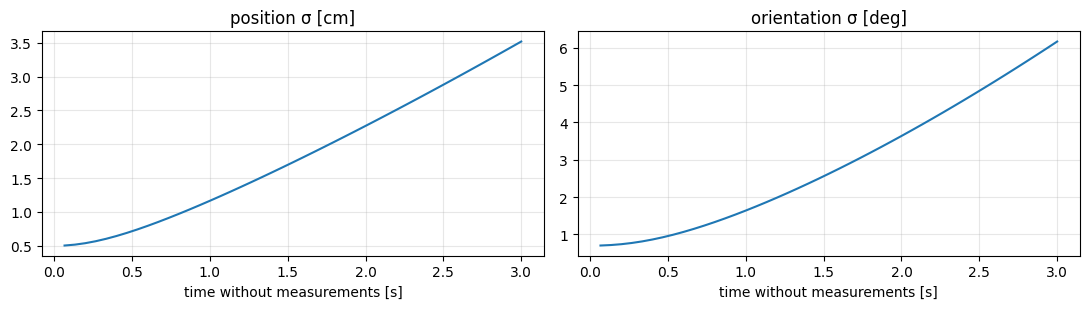

In [29]:
params = MotionParams()
x = dict(p=np.array([0.0, 0.0, 2.0]), v=np.zeros(3), q=np.array([1.0, 0, 0, 0]), w=np.zeros(3))
P = np.diag(np.r_[np.full(3, 0.005**2), np.full(3, 0.01**2), np.full(3, np.deg2rad(0.7)**2), np.full(3, 0.02**2)])

times, sig_p, sig_th = [], [], []
for k in range(1, 46):                                   # 3 s at 15 Hz
    x, P = predict(x, P, 1 / 15, params)
    times.append(k / 15)
    sig_p.append(100 * np.sqrt(np.diag(P)[0]))
    sig_th.append(np.degrees(np.sqrt(np.diag(P)[6])))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(times, sig_p); ax[0].set_title("position σ [cm]")
ax[1].plot(times, sig_th); ax[1].set_title("orientation σ [deg]")
for a in ax: a.set_xlabel("time without measurements [s]")
plt.tight_layout()

The uncertainty grows faster than linearly: an uncertain velocity is integrated into position. After a few seconds without estimates, the filter still has a useful guess, but it knows that this guess is getting worse. This is exactly the behaviour we want during an occlusion.

### 6.4 Checking $\mathbf F_x$ numerically

Derivations are easy to get wrong, so we check. We perturb the error state by a tiny $\delta\mathbf x$ in each direction, propagate both the nominal and the perturbed state with the *non-linear* model, and measure how the error changed. Each result is one column of $\mathbf F_x$.

In [30]:
x_test = dict(p=np.array([0.1, -0.2, 2.0]), v=np.array([0.1, 0.05, -0.02]),
              q=q_exp([0.3, -0.2, 0.5]), w=np.array([0.3, -0.2, 0.4]))
dt_test = 1 / 15

x_next = nominal_predict(x_test, dt_test)
F_numeric, eps = np.zeros((12, 12)), 1e-6
for i in range(12):
    d = np.zeros(12)
    d[i] = eps                                                     # perturb one error direction
    x_true_next = nominal_predict(state_plus(x_test, d), dt_test)
    F_numeric[:, i] = state_minus(x_true_next, x_next) / eps       # how did the error change?

diff = np.abs(error_state_jacobian(x_test, dt_test) - F_numeric)
names = ["δp", "δv", "δθ", "δω"]
print("largest |F_analytic - F_numeric| per 3x3 block")
print("      " + "".join(f"{n:>10}" for n in names))
for r in range(4):
    print(f"{names[r]:>4}  " + "".join(f"{diff[3*r:3*r+3, 3*c:3*c+3].max():10.1e}" for c in range(4)))

largest |F_analytic - F_numeric| per 3x3 block
              δp        δv        δθ        δω
  δp     1.4e-10   3.5e-11   0.0e+00   0.0e+00
  δv     0.0e+00   1.0e-12   0.0e+00   0.0e+00
  δθ     0.0e+00   0.0e+00   6.9e-11   8.9e-04
  δω     0.0e+00   0.0e+00   0.0e+00   2.7e-11


All blocks agree to numerical precision except $\partial\delta\boldsymbol\theta/\partial\delta\boldsymbol\omega$. The exact block is $\mathbf J_r(\boldsymbol\omega\Delta t)\,\Delta t$, with $\mathbf J_r$ the right Jacobian of SO(3), and we used the common approximation $\mathbf J_r\approx\mathbf I$. The difference is of order $\|\boldsymbol\omega\|\Delta t^2$, which is tiny compared to the process noise. The derivation is right.

## 7. Correction: using one pose estimate

### 7.1 The measurement model

The estimator measures position and orientation. We write the difference between measurement and prediction, the **residual** $\mathbf r$, directly in error-state coordinates:

$$
\mathbf r = \begin{bmatrix}\mathbf p_m - \mathbf p\\ \mathbf q_m \boxminus \mathbf q\end{bmatrix},
\qquad
\mathbf H = \frac{\partial\mathbf r}{\partial\delta\mathbf x} = \begin{bmatrix}\mathbf I & 0 & 0 & 0\\ 0 & 0 & \mathbf I & 0\end{bmatrix},
\qquad
\mathbf V_k = \mathrm{diag}(\sigma_{p,k}^2\mathbf I,\ \sigma_{\theta,k}^2\mathbf I).
$$

Because the orientation residual is already a small rotation vector, its Jacobian with respect to $\delta\boldsymbol\theta$ is just $\mathbf I$. This is one of the main practical advantages of the error-state formulation for 6D poses: no $4\times3$ quaternion Jacobian is needed.

Note the index $k$ on $\mathbf V_k$: **every frame brings its own uncertainty**. This is how the filter learns to trust a clear, close-range frame more than a turbid, far-away one. If your estimator provides no uncertainty, a constant $\mathbf V$ works too, but you lose this benefit.

In [31]:
def pose_measurement(x, p_meas, q_meas, sigma_p, sigma_theta):
    """Residual r, Jacobian H and noise V of one 6D pose estimate."""
    r = np.r_[p_meas - x["p"], q_boxminus(q_meas, x["q"])]
    H = np.zeros((6, 12))
    H[0:3, P_IDX] = np.eye(3)
    H[3:6, TH_IDX] = np.eye(3)
    V = np.diag(np.r_[np.full(3, sigma_p**2), np.full(3, sigma_theta**2)])
    return r, H, V

### 7.2 Update

This is the standard Kalman update (Solà eqs. 274-278). The gain $\mathbf K$ decides how far to move towards the measurement:

$$
\mathbf S = \mathbf H\mathbf P\mathbf H^\top + \mathbf V,\qquad
\mathbf K = \mathbf P\mathbf H^\top\mathbf S^{-1},\qquad
\delta\hat{\mathbf x} = \mathbf K\,\mathbf r,\qquad
\mathbf P \leftarrow (\mathbf I-\mathbf K\mathbf H)\mathbf P(\mathbf I-\mathbf K\mathbf H)^\top + \mathbf K\mathbf V\mathbf K^\top .
$$

$\mathbf S$ is the expected spread of the residual: prediction uncertainty plus measurement uncertainty. The last line is the Joseph form of the covariance update, which keeps $\mathbf P$ symmetric and positive definite.

In [32]:
def kalman_update(P, r, H, V):
    S = H @ P @ H.T + V                       # expected spread of the residual
    K = P @ H.T @ np.linalg.inv(S)            # Kalman gain
    dx = K @ r                                # estimated error state
    I_KH = np.eye(12) - K @ H
    P = I_KH @ P @ I_KH.T + K @ V @ K.T       # Joseph form
    return dx, P

### 7.3 Inject and reset

The estimated error is folded into the nominal state, $\mathbf x \leftarrow \mathbf x\oplus\delta\hat{\mathbf x}$. We already wrote this: `state_plus`.

After that, the error mean is zero again. The orientation error is now defined around a *new* nominal orientation, so the covariance is re-expressed around it (Solà eqs. 285-287):

$$
\mathbf P \leftarrow \mathbf G\,\mathbf P\,\mathbf G^\top,
\qquad
\mathbf G = \mathrm{diag}\big(\mathbf I,\ \mathbf I,\ \mathbf I - [\tfrac12\delta\hat{\boldsymbol\theta}]_\times,\ \mathbf I\big).
$$

In practice $\mathbf G\approx\mathbf I$ and many implementations skip it. We keep it for correctness.

In [33]:
def reset_covariance(P, dx):
    G = np.eye(12)
    G[TH_IDX, TH_IDX] = np.eye(3) - skew(0.5 * dx[TH_IDX])
    return G @ P @ G.T


def correct(x, P, r, H, V):
    """One correction = update, inject, reset."""
    dx, P = kalman_update(P, r, H, V)
    x = state_plus(x, dx)
    P = reset_covariance(P, dx)
    return x, P

**Test: the filter trusts good frames more than bad ones.** We take a predicted state that is 5 cm and 5° away from a measurement, and correct it once with a *good* estimate ($\sigma_p = 1$ cm) and once with a *poor* one ($\sigma_p = 5$ cm, as in turbid water). How far does the state move?

In [34]:
x_pred = dict(p=np.array([0.0, 0.0, 2.0]), v=np.zeros(3), q=np.array([1.0, 0, 0, 0]), w=np.zeros(3))
P_pred = np.diag(np.r_[np.full(3, 0.02**2), np.full(3, 0.05**2), np.full(3, np.deg2rad(2)**2), np.full(3, 0.05**2)])
p_meas = np.array([0.05, 0.0, 2.0])
q_meas = q_exp([0.0, 0.0, np.deg2rad(5)])

for label, s_p, s_th in [("good estimate", 0.01, np.deg2rad(1.5)), ("poor estimate", 0.05, np.deg2rad(6))]:
    x_new, P_new = correct(x_pred, P_pred, *pose_measurement(x_pred, p_meas, q_meas, s_p, s_th))
    print(f"{label}: moved {100 * x_new['p'][0]:.1f} of 5 cm and "
          f"{rotation_angle_deg(x_new['q'], x_pred['q']):.1f} of 5 deg,  "
          f"new σ_p = {100 * np.sqrt(P_new[0, 0]):.2f} cm")

good estimate: moved 4.0 of 5 cm and 3.2 of 5 deg,  new σ_p = 0.89 cm
poor estimate: moved 0.7 of 5 cm and 0.5 of 5 deg,  new σ_p = 1.86 cm


With a good estimate the filter moves most of the way. With a poor estimate it moves only a little and stays closer to its prediction. This single mechanism, the gain $\mathbf K$, is what averages out jitter over time.

That is the complete filter: `predict` from frame to frame, and `correct` with each pose estimate.

## 8. A first filter

We start the filter from the first estimate. We know the pose roughly (from that estimate) but know nothing about the velocities, so they start at zero with a large uncertainty.

In [35]:
def state_from_estimate(estimates, k):
    """Start (or restart) the filter from the estimate of frame k, with unknown velocities."""
    p, q = pose_at(estimates, k)
    x0 = dict(p=p, v=np.zeros(3), q=q, w=np.zeros(3))
    s_p, s_th = estimates.sigma_p[k], estimates.sigma_theta[k]
    P0 = np.diag(np.r_[np.full(3, s_p**2), np.full(3, 0.2**2), np.full(3, s_th**2), np.full(3, 0.5**2)])
    return x0, P0


def initial_state(estimates):
    k = int(np.argmax(estimates.valid.to_numpy()))            # first frame with an estimate
    x0, P0 = state_from_estimate(estimates, k)
    return k, x0, P0

The filter loop is short: for every frame, predict to the frame time, then correct if there is an estimate. For now, every estimate is accepted. We store everything the later sections need.

In [36]:
def run_naive_filter(estimates, params):
    k0, x, P = initial_state(estimates)
    dt = 1.0 / cfg.frame_rate
    track = {"x": [], "P": []}
    for k in range(k0, len(estimates)):
        if k > k0:
            x, P = predict(x, P, dt, params)
        if estimates.valid[k]:
            p_m, q_m = pose_at(estimates, k)
            x, P = correct(x, P, *pose_measurement(x, p_m, q_m, estimates.sigma_p[k], estimates.sigma_theta[k]))
        track["x"].append(x)
        track["P"].append(P)
    return track

In [37]:
def track_arrays(track):
    """Positions and orientations of a track as arrays over all frames."""
    return np.array([x["p"] for x in track["x"]]), np.array([x["q"] for x in track["x"]])


naive = run_naive_filter(estimates, params)
P_NAIVE, Q_NAIVE = track_arrays(naive)
results.loc["naive filter"] = metrics(P_NAIVE, Q_NAIVE)
results.round(2)

,pos RMSE [cm],rot RMSE [deg],pos jitter [cm],rot jitter [deg]
raw estimates,6.78,14.71,9.40,52.24
naive filter,2.20,14.59,0.77,6.11


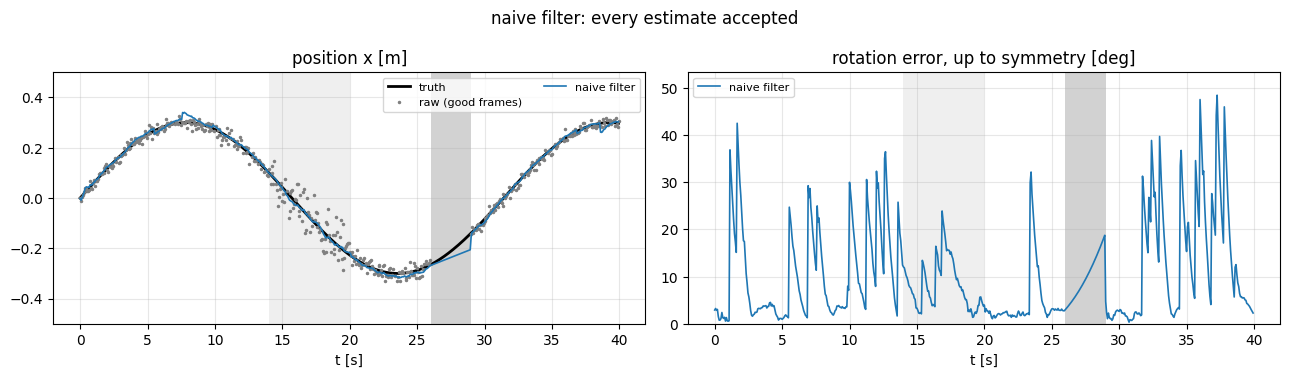

In [38]:
def plot_tracks(tracks, t_range=None, title=""):
    """Position x and rotation error of several tracks against the truth."""
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.8))
    axs[0].plot(t, P_TRUE[:, 0], "k", lw=2, label="truth")
    good = VALID & (KIND == "good")
    axs[0].plot(t[good], P_RAW[good, 0], ".", color="grey", ms=3, label="raw (good frames)")
    rot_max = 0.0
    for label, (P_est, Q_est), style in tracks:
        rot_err = np.array([rotation_error_deg(Q_est[k], Q_TRUE[k]) for k in range(len(t))])
        axs[0].plot(t, P_est[:, 0], style, lw=1.2, label=label)
        axs[1].plot(t, rot_err, style, lw=1.2, label=label)
        window = (t >= t_range[0]) & (t <= t_range[1]) if t_range else slice(None)
        rot_max = max(rot_max, rot_err[window].max())
    axs[1].set_ylim(0, 1.1 * rot_max)
    if t_range:                                                   # zoom: scale y to the truth in the window
        m = (t >= t_range[0]) & (t <= t_range[1])
        axs[0].set_ylim(P_TRUE[m, 0].min() - 0.08, P_TRUE[m, 0].max() + 0.08)
    else:
        axs[0].set_ylim(-0.5, 0.5)
    axs[0].set_title("position x [m]"); axs[0].legend(ncol=2, fontsize=8)
    axs[1].set_title("rotation error, up to symmetry [deg]"); axs[1].legend(fontsize=8)
    for a in axs:
        shade(a); a.set_xlabel("t [s]")
        if t_range: a.set_xlim(t_range)
    fig.suptitle(title); plt.tight_layout()


plot_tracks([("naive filter", (P_NAIVE, Q_NAIVE), "C0-")], title="naive filter: every estimate accepted")

Compared to the raw estimates, the position jitter already drops. But the naive filter trusts every estimate, including outliers and flips. Each flip yanks the orientation towards the wrong solution, and it takes several frames to recover. The rotation error shows these spikes clearly. We need to recognise bad estimates *before* we use them.

## 9. Robustness: symmetry flips and outlier gating

### 9.1 Symmetry flips

For a symmetric object, a flipped estimate is not really wrong, it is just the "other" equally valid answer. What breaks temporal consistency is the *jump* between the two. The fix is simple: for each estimate, consider all symmetric equivalents $\mathbf q_m\otimes\mathbf S_i$ and use the one closest to the prediction.

In [39]:
def resolve_symmetry(q_meas, q_pred):
    """Among the symmetric equivalents of q_meas, return the one closest to the prediction."""
    candidates = [q_mult(q_meas, S) for S in SYMMETRIES]
    return min(candidates, key=lambda q: rotation_angle_deg(q, q_pred))

In [40]:
q_pred = q_exp([0.1, 0.2, 0.3])
q_flipped = q_mult(q_boxplus(q_pred, [0.02, 0, 0]), SYMMETRY)
print("flipped estimate vs prediction  :", round(rotation_angle_deg(q_flipped, q_pred), 1), "deg")
print("after resolving the symmetry    :", round(rotation_angle_deg(resolve_symmetry(q_flipped, q_pred), q_pred), 1), "deg")

flipped estimate vs prediction  : 180.0 deg
after resolving the symmetry    : 1.1 deg


### 9.2 Outlier gating with the NIS

How far is a measurement from the prediction, *relative to how far it may be*? The **normalised innovation squared** answers exactly this:

$$
\nu = \mathbf r^\top\,\mathbf S^{-1}\,\mathbf r,\qquad \mathbf S = \mathbf H\mathbf P\mathbf H^\top + \mathbf V .
$$

It is the squared Mahalanobis distance of the residual. If the filter is right about its uncertainties, $\nu$ follows a $\chi^2$ distribution with 6 degrees of freedom (one per residual component). An estimate with $\nu$ above, say, the 99.9% quantile of $\chi^2_6$ ($\approx 22.5$) is very unlikely to be a good estimate, so we reject it.

The gate adapts automatically: after a long occlusion $\mathbf P$ is large, so the gate is wide and the filter can re-acquire the object. While tracking well, the gate is tight.

In [41]:
GATE = chi2.ppf(0.999, df=6)


def nis(P, r, H, V):
    S = H @ P @ H.T + V
    return r @ np.linalg.solve(S, r)


print(f"gate threshold: {GATE:.1f}")

gate threshold: 22.5


### 9.3 Re-initialisation: when the filter locks itself out

Gating has a dangerous failure mode. If the filter becomes *over-confident*, for example because its prediction drifted during an occlusion while $\mathbf P$ stayed small, then the correct estimates fall outside its gate. It rejects them, receives no correction, and stays wrong. The track is lost for good.

Real trackers guard against this with a simple rule: after several consecutive rejections, the filter no longer believes itself and restarts from the current estimate. One rejection is most likely an outlier. Five in a row most likely means the filter is wrong.

In [42]:
MAX_REJECTIONS = 5


def process_estimate(x, P, estimates, k):
    """Symmetry + gating + correction for frame k. Returns x, P, status, nis."""
    p_m, q_m = pose_at(estimates, k)
    q_m = resolve_symmetry(q_m, x["q"])
    r, H, V = pose_measurement(x, p_m, q_m, estimates.sigma_p[k], estimates.sigma_theta[k])
    nu = nis(P, r, H, V)
    if nu > GATE:
        return x, P, "rejected", nu
    x, P = correct(x, P, r, H, V)
    return x, P, "accepted", nu

### 9.4 The robust filter

The loop is the same as in Section 8, with the additions of this section for every estimate: resolve the symmetry, gate, and re-initialise after too many rejections in a row. We also record the status of every frame, the NIS values, and (for Section 13) the predictions.

In [43]:
def run_filter(estimates, params):
    k0, x, P = initial_state(estimates)
    dt = 1.0 / cfg.frame_rate
    track = {"x": [], "P": [], "x_pred": [], "P_pred": [], "F": [], "status": [], "nis": []}
    rejections = 0
    for k in range(k0, len(estimates)):
        if k > k0:
            track["F"].append(error_state_jacobian(x, dt))        # stored for the smoother
            x, P = predict(x, P, dt, params)
        track["x_pred"].append(x); track["P_pred"].append(P)
        status, nu = "no estimate", np.nan
        if estimates.valid[k]:
            x, P, status, nu = process_estimate(x, P, estimates, k)
            rejections = rejections + 1 if status == "rejected" else 0
            if rejections >= MAX_REJECTIONS:                        # the filter is lost: restart
                x, P = state_from_estimate(estimates, k)
                status, rejections = "re-initialised", 0
        track["x"].append(x); track["P"].append(P)
        track["status"].append(status); track["nis"].append(nu)
    return track

In [44]:
robust = run_filter(estimates, params)
P_ROB, Q_ROB = track_arrays(robust)
STATUS = np.array(robust["status"])

print("status of frames with an estimate, by what the estimate really was:")
print(pd.crosstab(KIND[VALID], STATUS[VALID]))

status of frames with an estimate, by what the estimate really was:
col_0    accepted  rejected
row_0                      
flip           20         0
good          499         0
outlier         0         8


The table shows the gate at work. Outliers are rejected. Flips are *accepted*, because after resolving the symmetry they are good estimates again. A 99.9% gate would also reject about one good estimate in a thousand by design. That is a good trade: rejecting a few good frames costs little, accepting a single outlier costs a lot.

## 10. Temporal consistency: results

In [45]:
results.loc["robust filter"] = metrics(P_ROB, Q_ROB)
results.round(2)

,pos RMSE [cm],rot RMSE [deg],pos jitter [cm],rot jitter [deg]
raw estimates,6.78,14.71,9.40,52.24
naive filter,2.20,14.59,0.77,6.11
robust filter,1.55,2.88,0.41,0.78


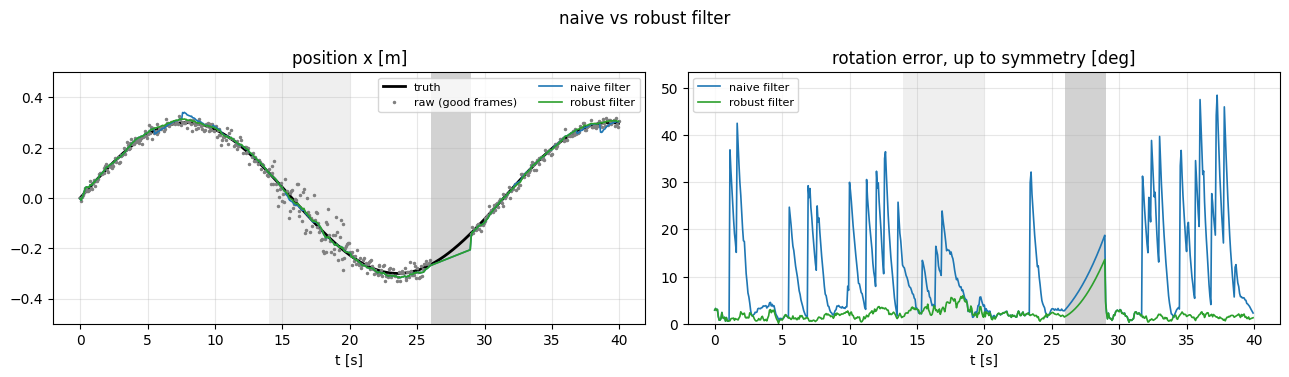

In [46]:
plot_tracks([("naive filter", (P_NAIVE, Q_NAIVE), "C0-"), ("robust filter", (P_ROB, Q_ROB), "C2-")],
            title="naive vs robust filter")

The robust filter removes the spikes, and all four numbers drop well below the raw estimates. To see the jitter reduction itself, zoom into a few seconds of the turbid period:

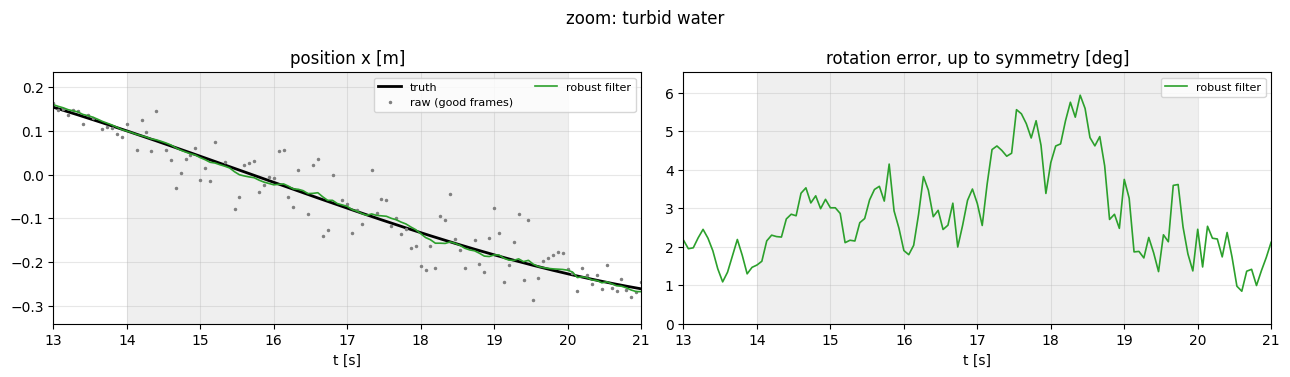

In [47]:
plot_tracks([("robust filter", (P_ROB, Q_ROB), "C2-")], t_range=(13, 21), title="zoom: turbid water")

The raw estimates scatter by several centimetres, while the filtered track follows the truth smoothly. Notice also that the filter adapts: when the per-frame uncertainty grows in turbid water, each estimate gets less weight.

### 10.1 Does the filter know how uncertain it is?

A good filter reports an uncertainty that matches its actual error. Here we plot the error of the robust filter together with its $\pm3\sigma$ bounds from $\mathbf P$.

To compute the error of the full state, we need the true state at frame $k$. For a symmetric object we express it in the same symmetric branch as the estimate. Flipping the object frame by $\mathbf S$ also rotates the angular velocity, which is expressed in the object frame: $\boldsymbol\omega' = \mathbf R(\mathbf S)^\top\boldsymbol\omega$.

In [48]:
def true_state(truth, k, q_reference):
    """True state at frame k, in the symmetric branch closest to q_reference."""
    q = truth.loc[k, ["qw", "qx", "qy", "qz"]].to_numpy(dtype=float)
    w = truth.loc[k, ["wx", "wy", "wz"]].to_numpy(dtype=float)
    S = min(SYMMETRIES, key=lambda S: rotation_angle_deg(q_mult(q, S), q_reference))
    return dict(p=truth.loc[k, ["px", "py", "pz"]].to_numpy(dtype=float),
                v=truth.loc[k, ["vx", "vy", "vz"]].to_numpy(dtype=float),
                q=q_mult(q, S), w=q_to_R(S).T @ w)

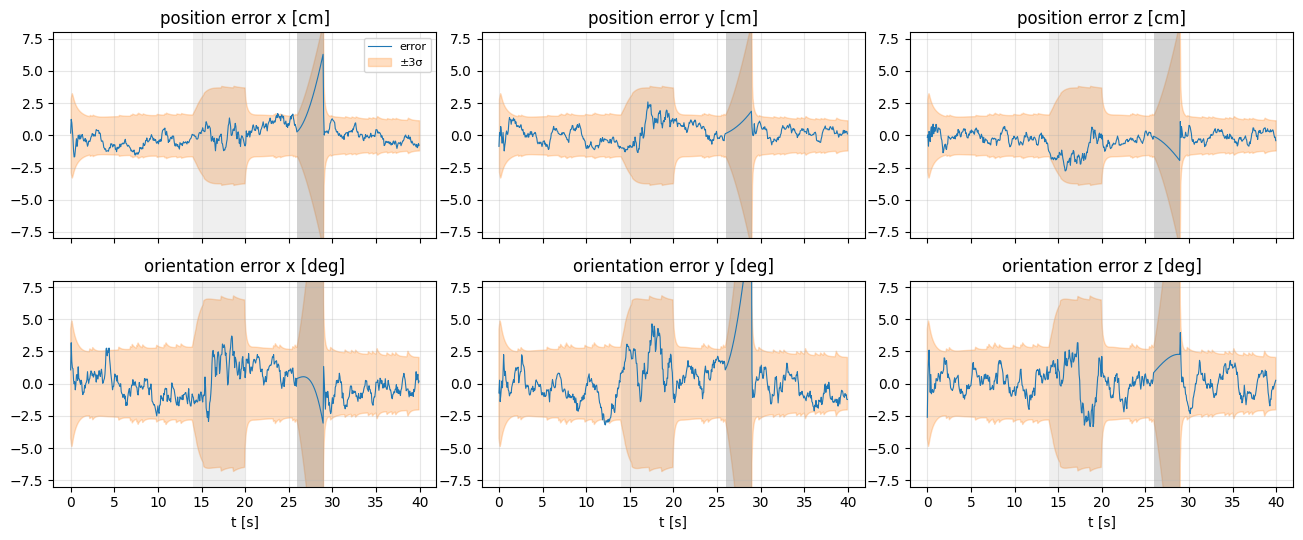

In [49]:
errors = np.array([state_minus(true_state(truth, k, x["q"]), x) for k, x in enumerate(robust["x"])])
sigma = np.sqrt(np.array([np.diag(P) for P in robust["P"]]))

fig, axs = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True)
for i, c in enumerate("xyz"):
    for row, (block, scale, unit) in enumerate([(P_IDX, 100, "cm"), (TH_IDX, np.degrees(1), "deg")]):
        a, col = axs[row, i], block.start + i
        a.plot(t, scale * errors[:, col], lw=0.8, label="error")
        a.fill_between(t, -3 * scale * sigma[:, col], 3 * scale * sigma[:, col], color="C1", alpha=0.25, label="±3σ")
        a.set_title(f"{'position' if row == 0 else 'orientation'} error {c} [{unit}]"); shade(a)
axs[0, 0].set_ylim(-8, 8); axs[1, 0].set_ylim(-8, 8)
for a in axs[0, 1:]: a.set_ylim(-8, 8)
for a in axs[1, 1:]: a.set_ylim(-8, 8)
axs[0, 0].legend(fontsize=8)
for a in axs[1]: a.set_xlabel("t [s]")
plt.tight_layout()

The error stays inside the band. The band widens in turbid water (the estimates are worse) and opens up during the occlusion (only prediction). When estimates return, it closes within a few frames. This honest uncertainty is valuable downstream, for example to decide whether a pose is good enough to act on.

## 11. Tuning: smoothness versus lag

The process noise $\sigma_a,\sigma_\alpha$ sets how much the filter trusts its motion model. Let us scale both by a common factor and see what happens.

In [50]:
scales = [0.1, 0.3, 1, 3, 10, 30, 100]
tuning = {}
for s in scales:
    tr = run_filter(estimates, MotionParams(params.sigma_a * s, params.sigma_alpha * s))
    tuning[s] = metrics(*track_arrays(tr))
tuning = pd.DataFrame(tuning).T
tuning.index.name = "Q scale"
tuning.round(2)

,pos RMSE [cm],rot RMSE [deg],pos jitter [cm],rot jitter [deg]
Q scale,,,,
0.1,3.05,6.82,1.16,1.98
0.3,4.17,5.66,0.91,1.32
1.0,1.55,2.88,0.41,0.78
3.0,1.48,2.99,0.63,1.23
10.0,2.71,5.45,1.07,2.07
30.0,4.66,11.34,1.71,3.26
100.0,9.89,19.88,2.75,5.06


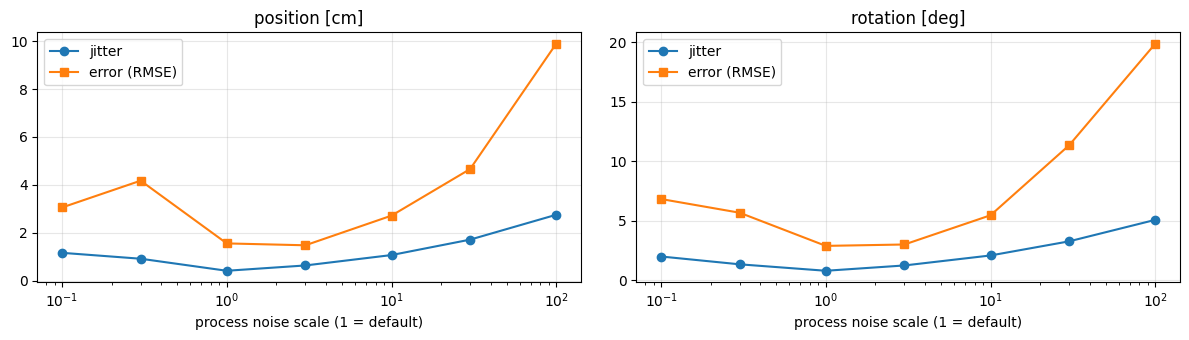

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))
axs[0].semilogx(tuning.index, tuning["pos jitter [cm]"], "o-", label="jitter")
axs[0].semilogx(tuning.index, tuning["pos RMSE [cm]"], "s-", label="error (RMSE)")
axs[0].set_title("position [cm]")
axs[1].semilogx(tuning.index, tuning["rot jitter [deg]"], "o-", label="jitter")
axs[1].semilogx(tuning.index, tuning["rot RMSE [deg]"], "s-", label="error (RMSE)")
axs[1].set_title("rotation [deg]")
for a in axs: a.set_xlabel("process noise scale (1 = default)"); a.legend()
plt.tight_layout()

Both ends are worse than the middle, for different reasons:

* **Large process noise** (right): the filter trusts the estimates a lot and its motion model little. It follows the jitter of every estimate, so jitter and error grow towards those of the raw estimates. During the occlusion it also extrapolates a noisy velocity.
* **Small process noise** (left): the filter trusts its constant-velocity model a lot. When the real motion changes, the prediction lags behind, while $\mathbf P$ stays small and the filter believes it is right. Soon the correct estimates fall outside its gate and are rejected: the lock-out from Section 9.3. After five rejections it re-initialises, and the track jumps back. This lag plus these jumps make both error *and* jitter worse.

The best setting lies in between. There is no universal value: it depends on how smoothly your object (or your camera) really moves. Section 12 gives a principled way to check a choice. Let us look at the two extremes directly:

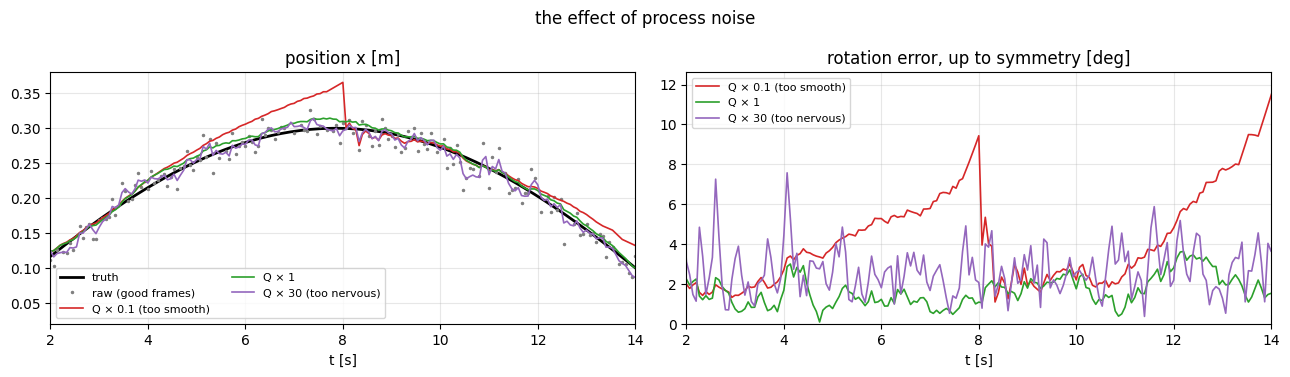

In [52]:
too_smooth = track_arrays(run_filter(estimates, MotionParams(params.sigma_a * 0.1, params.sigma_alpha * 0.1)))
too_nervous = track_arrays(run_filter(estimates, MotionParams(params.sigma_a * 30, params.sigma_alpha * 30)))
plot_tracks([("Q × 0.1 (too smooth)", too_smooth, "C3-"), ("Q × 1", (P_ROB, Q_ROB), "C2-"),
             ("Q × 30 (too nervous)", too_nervous, "C4-")], t_range=(2, 14), title="the effect of process noise")

The red track (too smooth) slowly drifts away from the truth, most visibly in the rotation error, and then jumps back each time the filter re-initialises. The purple track (too nervous) stays close to the truth on average but shakes with the estimates. The green track is both smooth and on target.

## 12. Is the filter honest? NEES and NIS

The tuning plot shows the *result*, but it needs ground truth. Two statistics check whether the filter's uncertainty is realistic (Bar-Shalom et al., Sec. 5.4):

**NEES** (normalised estimation error squared) needs ground truth, so it is the tool for simulation:
$$\epsilon_k = \delta\mathbf x_k^\top\,\mathbf P_k^{-1}\,\delta\mathbf x_k \;\sim\; \chi^2_{12}\quad\text{if the filter is consistent.}$$

**NIS** needs no ground truth, so it is the tool for **real data**. We already compute it for gating: for accepted estimates it should follow $\chi^2_6$, with mean $6$.

A single run is noisy, so for NEES we repeat the experiment with $N$ different random seeds and average. The truth stays the same, only the estimator noise changes. Averaged over $N$ runs, $N\bar\epsilon_k\sim\chi^2_{12N}$, which gives a 95% acceptance band.

In [53]:
def nees_one_run(seed, params):
    tr_mc, est_mc = simulate(SimConfig(seed=seed))
    track = run_filter(est_mc, params)
    nees = []
    for k, x in enumerate(track["x"]):
        e = state_minus(true_state(tr_mc, k, x["q"]), x)
        nees.append(e @ np.linalg.solve(track["P"][k], e))
    accepted = np.array(track["status"]) == "accepted"
    return np.array(nees), np.array(track["nis"])[accepted]

In [54]:
N = 20
runs = [nees_one_run(100 + s, params) for s in range(N)]
average_nees = np.mean([r[0] for r in runs], axis=0)
all_nis = np.concatenate([r[1] for r in runs])
lo, hi = chi2.ppf([0.025, 0.975], 12 * N) / N
print(f"mean NEES = {average_nees[15:].mean():.2f}  (ideal 12), "
      f"fraction inside 95% band = {np.mean((average_nees[15:] > lo) & (average_nees[15:] < hi)):.0%}")
print(f"mean NIS  = {all_nis.mean():.2f}  (ideal 6)")

mean NEES = 11.08  (ideal 12), fraction inside 95% band = 52%
mean NIS  = 6.08  (ideal 6)


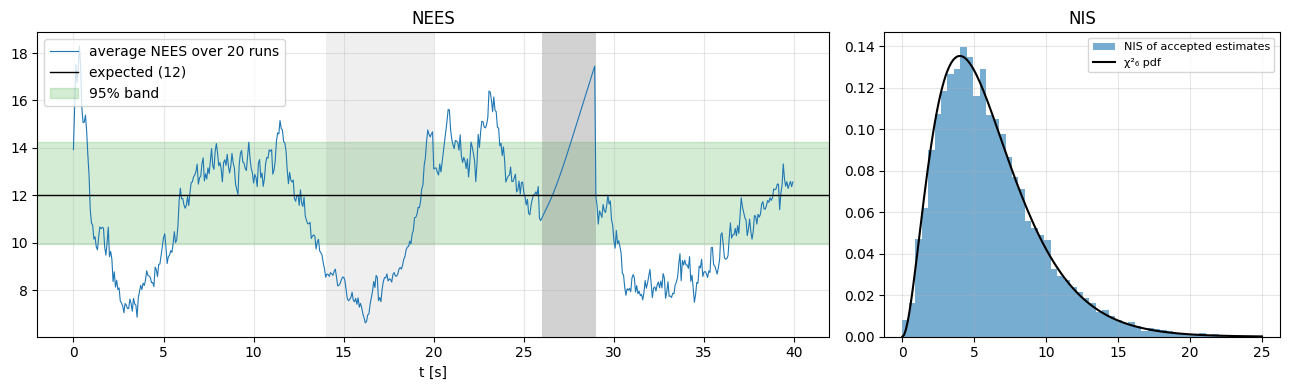

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
axs[0].plot(t, average_nees, lw=0.8, label=f"average NEES over {N} runs")
axs[0].axhline(12, color="k", lw=1, label="expected (12)")
axs[0].axhspan(lo, hi, color="C2", alpha=0.2, label="95% band")
shade(axs[0]); axs[0].set_xlabel("t [s]"); axs[0].set_title("NEES"); axs[0].legend()
xs = np.linspace(0, 25, 200)
axs[1].hist(all_nis, bins=50, density=True, alpha=0.6, label="NIS of accepted estimates")
axs[1].plot(xs, chi2.pdf(xs, 6), "k", label="χ²₆ pdf")
axs[1].set_title("NIS"); axs[1].legend(fontsize=8)
plt.tight_layout()

The NIS matches the $\chi^2_6$ distribution very well, and the NEES averages close to 12. So on the whole, the filter's uncertainty is realistic.

The NEES curve does wander, though, from about 7 to 17, instead of staying inside the band. This is not random: all runs share the same true motion, only the estimator noise differs. Where the true motion is steady, the constant-velocity model works better than $\mathbf Q$ assumes, and the filter is slightly cautious (NEES below 12). Where the motion changes, and especially in the occlusion where the filter can only extrapolate, the model is worse than assumed, and the filter is slightly over-confident (NEES above 12). A real motion is never exactly a random walk, so a single $\mathbf Q$ can only be right on average. That is normal and fine, as long as the deviations stay moderate.

In general, if NEES sits clearly **above** the band, the filter is over-confident: $\mathbf P$ is too small, usually because $\mathbf Q$ is too small or the reported $\sigma$ of the estimator is too optimistic. If it sits clearly **below**, the filter is too cautious and smooths less than it could. The NIS histogram gives the same message on real data, where no ground truth exists. This is the practical way to tune $\mathbf Q$, and to check whether the uncertainty reported by a pose estimator can be trusted.

## 13. Filter versus smoother: using future frames

A filter is **causal**: at frame $k$ it only uses frames $0\ldots k$. That is necessary in real time. But if a sequence is processed offline, frame $k$ can also benefit from frames *after* it. The **Rauch-Tung-Striebel (RTS) smoother** runs backwards over the stored filter results and combines each filtered estimate with the smoothed estimate of the next frame:

$$
\mathbf C_k = \mathbf P_k\,\mathbf F_k^\top\,(\mathbf P^-_{k+1})^{-1},\qquad
\mathbf x^s_k = \mathbf x_k \oplus \mathbf C_k\,(\mathbf x^s_{k+1}\ominus\mathbf x^-_{k+1}),\qquad
\mathbf P^s_k = \mathbf P_k + \mathbf C_k(\mathbf P^s_{k+1}-\mathbf P^-_{k+1})\mathbf C_k^\top
$$

Here $\mathbf x_k,\mathbf P_k$ are the filtered values, $\mathbf x^-_{k+1},\mathbf P^-_{k+1}$ the predictions, and $\mathbf F_k$ the Jacobian of the step from $k$ to $k+1$. The filter already stored all of these. The error-state operations $\oplus,\ominus$ make it work for orientations too.

In [56]:
def rts_smoother(track):
    n = len(track["x"])
    xs, Ps = [None] * n, [None] * n
    xs[-1], Ps[-1] = track["x"][-1], track["P"][-1]
    for k in range(n - 2, -1, -1):
        F, P_pred_next = track["F"][k], track["P_pred"][k + 1]
        C = track["P"][k] @ F.T @ np.linalg.inv(P_pred_next)
        xs[k] = state_plus(track["x"][k], C @ state_minus(xs[k + 1], track["x_pred"][k + 1]))
        Ps[k] = track["P"][k] + C @ (Ps[k + 1] - P_pred_next) @ C.T
    return {"x": xs, "P": Ps}

In [57]:
smoothed = rts_smoother(robust)
P_SM, Q_SM = track_arrays(smoothed)
results.loc["RTS smoother"] = metrics(P_SM, Q_SM)
results.round(2)

,pos RMSE [cm],rot RMSE [deg],pos jitter [cm],rot jitter [deg]
raw estimates,6.78,14.71,9.40,52.24
naive filter,2.20,14.59,0.77,6.11
robust filter,1.55,2.88,0.41,0.78
RTS smoother,0.55,0.99,0.02,0.06


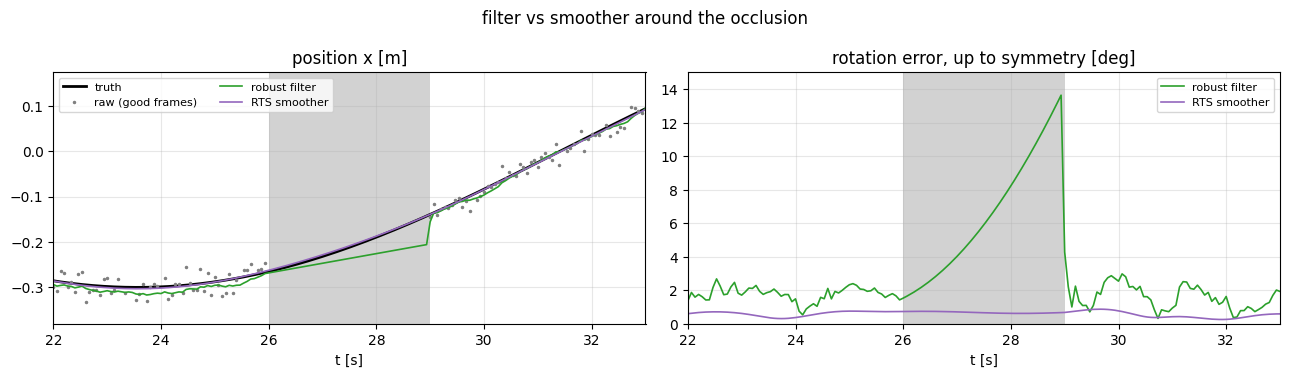

In [58]:
plot_tracks([("robust filter", (P_ROB, Q_ROB), "C2-"), ("RTS smoother", (P_SM, Q_SM), "C4-")],
            t_range=(22, 33), title="filter vs smoother around the occlusion")

The smoother is better everywhere, and most clearly in the occlusion: the filter can only extrapolate into the gap and then has to catch up, while the smoother knows where the object reappeared and bridges the gap smoothly from both sides.

This idea, using all frames jointly instead of one at a time, is exactly what **factor-graph optimisation** does in a more general and non-linear way: every pose estimate and every motion constraint becomes a factor, and all poses are optimised together. For linear-Gaussian problems the RTS smoother and the factor graph give the same answer. For real, non-linear problems the factor graph can re-linearise and usually does better.

## 14. Summary

| step | what it does for temporal consistency |
|---|---|
| **state with velocities** | lets the filter predict the next frame |
| **prediction** $\mathbf F_x,\mathbf Q$ | provides an expectation to compare every estimate with, and bridges dropouts with growing uncertainty |
| **correction** with per-frame $\mathbf V_k$ | blends prediction and estimate by their uncertainties, which averages out jitter and gives less weight to poor frames |
| **error state** $\delta\boldsymbol\theta$ | handles orientation cleanly: minimal covariance, and a simple Jacobian $\mathbf H$ for 6D pose |
| **symmetry resolution** | removes flips between equivalent solutions |
| **NIS gating** | rejects outliers before they can corrupt the track |
| **re-initialisation** | recovers when the filter itself has become wrong and would reject every good estimate |
| **tuning $\mathbf Q$** | chooses between smoothness and lag, checked with NEES / NIS |
| **smoother** | uses future frames offline, the bridge to factor-graph optimisation |

**Where to go from here.** The prediction is the weakest part of this filter: a constant-velocity model can only guess how the camera moves. If the vehicle carrying the camera has an IMU (and a DVL), the prediction can be driven by these sensors instead, with the object static in the world. That is the classical IMU-driven ESKF from Solà's document. It predicts much better, especially during long dropouts, and the correction step stays exactly as it is here.

## References

* J. Solà, *Quaternion kinematics for the error-state Kalman filter*, 2017. [arXiv:1711.02508](https://arxiv.org/abs/1711.02508)
* R. Labbe, *Kalman and Bayesian Filters in Python*. [GitHub](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python)
* Y. Bar-Shalom, X. R. Li, T. Kirubarajan, *Estimation with Applications to Tracking and Navigation*, Wiley, 2001.
* H. E. Rauch, F. Tung, C. T. Striebel, *Maximum likelihood estimates of linear dynamic systems*, AIAA Journal, 1965.
* J. Solà, J. Deray, D. Atchuthan, *A micro Lie theory for state estimation in robotics*, 2018. [arXiv:1812.01537](https://arxiv.org/abs/1812.01537)
* F. Dellaert, M. Kaess, *Factor Graphs for Robot Perception*, Foundations and Trends in Robotics, 2017.